In [1]:
from __future__ import annotations

import gymnasium as gym
import numpy as np
from stable_baselines3 import TD3, HerReplayBuffer
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.callbacks import EvalCallback
from stable_baselines3.common.vec_env import DummyVecEnv
import gymnasium_robotics
from pathlib import Path
import sys
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import time
import copy
from copy import deepcopy
from torch import optim
from typing import Dict, Optional, Tuple, List, Any
from IPython.display import HTML
from matplotlib.animation import FuncAnimation

import json
import pickle


# Resolve repository src path robustly when running notebook in-place.
repo_root = Path.cwd()
while repo_root != repo_root.parent and not (repo_root / 'src').exists():
    repo_root = repo_root.parent
sys.path.insert(0, str(repo_root / 'src'))


from gym_robotics_networks import FactorisedTwinCriticFetch, MLPPolicyActor, StandardTwinCriticFetch, GaussianPolicyActorSAC, RunningMeanStd
from environments.gym_robotics_manipulators import make_env
from utils import (set_seed, estimate_fisher_diag, compute_embedding_drift, collect_weight_snapshot, sample_goals, get_free_cells, evaluate_policy, analyse_seen_goal_embeddings,
                   plot_sa_encoder_changes_across_tasks, compute_weight_change_from_snapshots, keep_last_fraction_of_buffer_continuous, keep_goal_reaching_episodes, TrajectoryReplayBufferContinuous, evaluate_policy_with_success)
from visualisations import visualise_embeddings, visualise_q_table, print_goal_embedding_similarity, plot_full_embedding_dashboard_2d_html, plot_min_steps_and_min_time, plot_psi_embeddings_2d
from networks import snapshot_named_parameters
from loss_functions import (
    sigreg_loss,
    online_goal_separation_loss,
    norm_penalty_loss_l1,
)

from trainer import sac_train_tbtrl_separated

DEVICE = 'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu')
print('Using device:', DEVICE)

gym.register_envs(gymnasium_robotics)

PROJECT_DIR = "tbtrl_sac_experiments_multi_env_fetchpick"

AdroitHandRelocateDense-v1, AdroitHandHammerDense-v1, AdroitHandDoorDense-v1 environment's reward functions were updated in v1.2.1 without an environment version update. Therefore, use gymnasium-robotics==1.2.0 for v1 reproducibility or use v2 in gymnasium-robotics>=1.4.3. See https://github.com/Farama-Foundation/Gymnasium-Robotics/pull/220 for more details


Using device: mps


## Setup

In [5]:
MAX_EPISODE_STEPS = 50


CROSS_ENV_TASKS = [
    # {"env_id": "FetchPush-v4", "goal": np.array([1.44, 0.45, 0.42])},
    # FetchPush tasks
    {"env_id": "FetchPickAndPlace-v4", "goal": np.array([1.20, 0.65, 0.60])},
    {"env_id": "FetchPickAndPlace-v4", "goal": np.array([1.25, 0.70, 0.55])},
    {"env_id": "FetchPickAndPlace-v4", "goal": np.array([1.50, 0.20, 0.50])},
    {"env_id": "FetchPickAndPlace-v4", "goal": np.array([1.30, 0.75, 0.58])},
    {"env_id": "FetchPickAndPlace-v4", "goal": np.array([1.44, 0.45, 0.50])},


]


SEEDS = [
    123,
    # 456,
]


# Derive a simple list of goals for compatibility with any code that
# still expects TASK_GOALS_LIST.
TASK_GOALS_LIST = [
    np.asarray(
        spec["goal"],
        dtype=np.float32,
    ).copy()
    for spec in CROSS_ENV_TASKS
]


NUM_TASKS = len(TASK_GOALS_LIST)


BUFFER_CAPACITY = 1_000_000


TOTAL_STEPS_PER_TASK = 1_000_000
RECOVERY_STEPS_PER_TASK = 300_000


WARMUP_STEPS = 10000
BATCH_SIZE = 256
EVAL_FREQ = 10_000


GAMMA = 0.98
TAU = 0.005
LR_ACTOR = 5e-4
LR_CRITIC = 5e-4
LR_ENT_COEF = 5e-4


SUCCESS_THRESHOLD = 0.8
EARLY_STOP_PATIENCE = 3


# ------------------------------------------------------------
# TBTRL regularization settings
# ------------------------------------------------------------


SIGREG_COEF = 1e-5
SKETCH_DIM = 64


GOAL_SEPARATION_COEF = 1e-5
GOAL_SEPARATION_TARGET_COSINE = 0.85


PHI_RAW_NORM_COEF = 3e-3
PSI_RAW_NORM_COEF = 3e-3


# Soft excess-norm thresholds:
# penalty = 0 whenever norm <= target.
PHI_NORM_TARGET = 5.0
PSI_NORM_TARGET = 5.0


# ------------------------------------------------------------
# Replay and recovery settings
# ------------------------------------------------------------


# Scratch has no old-task replay by definition.
SCRATCH_REPLAY_RATIO = 0.0


# TBTRL starts using old task replay on Task 1 onward.
TBTRL_REPLAY_RATIO = 0.5


# During per-task recovery, use no replay initially.
RECOVERY_REPLAY_RATIO = 0.0
REPLAY_LOSS_COEF = 0.5
# If final TBTRL model has lower success than this on an old
# task, run an independent recovery fine-tuning experiment.
RETENTION_THRESHOLD = 0.80


# Keep only this fraction of each finished task buffer for
# future replay. Adjust based on memory availability.
BUFFER_KEEP_FRACTION = 0.30


# ------------------------------------------------------------
# Save folders
# ------------------------------------------------------------


SAVE_ROOT = (
    Path(PROJECT_DIR)
    / "fetch_crossenv_sac_tbtrl_experiments"
)


SCRATCH_SAVE_DIR = SAVE_ROOT / "scratch"
TBTRL_SAVE_DIR = SAVE_ROOT / "tbtrl"
RECOVERY_SAVE_DIR = SAVE_ROOT / "recovery"


for directory in [
    SAVE_ROOT,
    SCRATCH_SAVE_DIR,
    TBTRL_SAVE_DIR,
    RECOVERY_SAVE_DIR,
]:
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )



# ============================================================
# Goal and file helpers
# ============================================================


def make_goal_tag(
    goal: np.ndarray,
) -> str:
    goal = np.asarray(
        goal,
        dtype=np.float32,
    )

    return (
        f"x{goal[0]:.3f}_"
        f"y{goal[1]:.3f}_"
        f"z{goal[2]:.3f}"
    ).replace(
        ".",
        "p",
    ).replace(
        "-",
        "neg",
    )



def save_json(
    object_to_save,
    filepath,
):
    filepath = Path(filepath)

    filepath.parent.mkdir(
        parents=True,
        exist_ok=True,
    )

    with open(
        filepath,
        "w",
        encoding="utf-8",
    ) as file:
        json.dump(
            object_to_save,
            file,
            indent=2,
        )



def _to_serializable(obj):
    """
    Convert NumPy arrays and common numeric types to JSON-serializable Python objects.
    """
    import numpy as np

    if isinstance(obj, np.ndarray):
        return obj.astype(float).tolist()

    if isinstance(
        obj,
        (np.integer, np.int64, np.int32, np.int16, np.int8),
    ):
        return int(obj)

    if isinstance(
        obj,
        (np.floating, np.float64, np.float32, np.float16),
    ):
        return float(obj)

    if isinstance(obj, dict):
        return {
            (
                int(k)
                if isinstance(k, (np.integer, int))
                else str(k)
            ): _to_serializable(v)
            for k, v in obj.items()
        }

    if isinstance(obj, (list, tuple)):
        return [_to_serializable(v) for v in obj]

    # Booleans must be checked before int/float in some Python versions,
    # but here we only need to ensure they pass through unchanged.
    if isinstance(obj, (bool, int, float, str, type(None))):
        return obj

    # Fallback: convert anything with .tolist() if present, else stringify.
    if hasattr(obj, "tolist"):
        try:
            return _to_serializable(obj.tolist())
        except Exception:
            return str(obj)

    return str(obj)



def save_sac_tbtrl_task(
    save_root,
    run_name: str,
    seed: int,
    task_id: int,
    goal: np.ndarray,
    actor,
    critic,
    critic_target,
    buffer,
    eval_returns,
    eval_success_rates,
    eval_final_distances,
    min_steps,
    min_time,
    extra_metadata: dict | None = None,
):
    """
    Save networks, replay buffer, metrics, and task metadata.

    Network weights:
        networks.pt

    Replay buffer:
        replay_buffer.pkl

    Curves/configuration/embedding diagnostics:
        metadata.json
    """
    task_dir = (
        Path(save_root)
        / run_name
        / f"seed_{seed}"
        / f"task_{task_id:02d}_{make_goal_tag(goal)}"
    )

    task_dir.mkdir(
        parents=True,
        exist_ok=True,
    )

    torch.save(
        {
            "run_name": run_name,
            "seed": int(seed),
            "task_id": int(task_id),
            "goal": np.asarray(
                goal,
                dtype=np.float32,
            ).copy(),

            "actor_state_dict": deepcopy(
                actor.state_dict()
            ),

            "critic_state_dict": deepcopy(
                critic.state_dict()
            ),

            "critic_target_state_dict": deepcopy(
                critic_target.state_dict()
            ),
        },
        task_dir / "networks.pt",
    )

    with open(
        task_dir / "replay_buffer.pkl",
        "wb",
    ) as file:
        pickle.dump(
            buffer,
            file,
            protocol=pickle.HIGHEST_PROTOCOL,
        )

    # Convert extra_metadata to a JSON-serializable structure.
    if extra_metadata is None:
        extra_metadata_serializable = None
    else:
        extra_metadata_serializable = _to_serializable(extra_metadata)

    metadata = {
        "run_name": run_name,
        "seed": int(seed),
        "task_id": int(task_id),

        "goal": np.asarray(
            goal,
            dtype=np.float32,
        ).astype(
            float
        ).tolist(),

        "min_steps": int(min_steps),
        "min_time": float(min_time),

        "eval_returns": [
            [
                int(step),
                float(value),
            ]
            for step, value in eval_returns
        ],

        "eval_success_rates": [
            [
                int(step),
                float(value),
            ]
            for step, value in eval_success_rates
        ],

        "eval_final_distances": [
            [
                int(step),
                float(value),
            ]
            for step, value in eval_final_distances
        ],

        "buffer_stats": (
            buffer.stats()
            if hasattr(buffer, "stats")
            else None
        ),

        "extra_metadata": extra_metadata_serializable,
    }

    save_json(
        metadata,
        task_dir / "metadata.json",
    )

    return task_dir



# ============================================================
# Environment / dimension helpers
# ============================================================


def get_fetch_dimensions(
    env_id: str,
    goal: np.ndarray,
    seed: int,
):
    """
    Read state, goal, and action dimensions from the actual
    Fetch environment.
    """
    probe_env = make_env(
        env_id=env_id,
        goal=goal,
        seed=seed,
    )

    obs_dict, _ = probe_env.reset(
        seed=seed,
    )

    state_dim = (
        int(
            obs_dict[
                "observation"
            ].shape[0]
        )
        + int(
            obs_dict[
                "achieved_goal"
            ].shape[0]
        )
    )

    goal_dim = int(
        obs_dict[
            "desired_goal"
        ].shape[0]
    )

    action_dim = int(
        probe_env.action_space.shape[0]
    )

    probe_env.close()

    return (
        state_dim,
        goal_dim,
        action_dim,
    )



def make_factorised_sac_components(
    state_dim: int,
    goal_dim: int,
    action_dim: int,
):
    """
    Fresh actor, factorised twin critic, and target critic.
    """
    actor = GaussianPolicyActorSAC(
        state_dim=state_dim,
        action_dim=action_dim,
        goal_dim=goal_dim,
        net_arch=[256, 256],
        activation_fn=nn.ReLU,
    ).to(DEVICE)

    critic = FactorisedTwinCriticFetch(
        state_dim=state_dim,
        action_dim=action_dim,
        goal_dim=goal_dim,
        hidden_dim=256,
        latent_dim=64,
        activation_fn=nn.ReLU,
    ).to(DEVICE)

    critic_target = FactorisedTwinCriticFetch(
        state_dim=state_dim,
        action_dim=action_dim,
        goal_dim=goal_dim,
        hidden_dim=256,
        latent_dim=64,
        activation_fn=nn.ReLU,
    ).to(DEVICE)

    return (
        actor,
        critic,
        critic_target,
    )

def make_actor(
    state_dim: int,
    goal_dim: int,
    action_dim: int,
):
    """
    Fresh actor, factorised twin critic, and target critic.
    """
    actor = GaussianPolicyActorSAC(
        state_dim=state_dim,
        action_dim=action_dim,
        goal_dim=goal_dim,
        net_arch=[256, 256],
        activation_fn=nn.ReLU,
    ).to(DEVICE)

    return actor



# ============================================================
# Fixed embedding probes
# ============================================================


def make_fixed_sa_probes(
    env_id: str,
    goal: np.ndarray,
    seed: int,
    num_probes: int = 32,
):
    """
    Make fixed state-action probes.

    Reuse exactly the same probes after every sequential task
    so changes in phi can be interpreted as representation
    changes rather than different sampled inputs.
    """
    probe_env = make_env(
        env_id=env_id,
        goal=goal,
        seed=seed + 10_000,
    )

    states = []
    actions = []

    for probe_index in range(num_probes):
        obs_dict, _ = probe_env.reset(
            seed=seed + 10_000 + probe_index,
        )

        state = np.concatenate(
            [
                np.asarray(
                    obs_dict["observation"],
                    dtype=np.float32,
                ),
                np.asarray(
                    obs_dict["achieved_goal"],
                    dtype=np.float32,
                ),
            ],
            axis=-1,
        ).astype(np.float32)

        action = probe_env.action_space.sample().astype(
            np.float32
        )

        states.append(state)
        actions.append(action)

    probe_env.close()

    return (
        torch.as_tensor(
            np.asarray(
                states,
                dtype=np.float32,
            ),
            dtype=torch.float32,
            device=DEVICE,
        ),
        torch.as_tensor(
            np.asarray(
                actions,
                dtype=np.float32,
            ),
            dtype=torch.float32,
            device=DEVICE,
        ),
    )



# ============================================================
# Evaluation helper
# ============================================================


def evaluate_tbtrl_actor(
    actor,
    env_id: str,
    goal: np.ndarray,
    seed: int,
    episodes: int = 20,
):
    """
    Evaluate a custom SAC actor deterministically on one goal.

    This assumes the runs use:
        normalize_state_inputs=False
        normalize_goal_inputs=False
    """
    eval_env = make_env(
        env_id=env_id,
        goal=np.asarray(
            goal,
            dtype=np.float32,
        ).copy(),
        seed=seed,
    )

    def policy_fn(obs_dict):
        state = np.concatenate(
            [
                np.asarray(
                    obs_dict["observation"],
                    dtype=np.float32,
                ),
                np.asarray(
                    obs_dict["achieved_goal"],
                    dtype=np.float32,
                ),
            ],
            axis=-1,
        ).astype(np.float32)

        desired_goal = np.asarray(
            obs_dict["desired_goal"],
            dtype=np.float32,
        )

        state_t = torch.as_tensor(
            state,
            dtype=torch.float32,
            device=DEVICE,
        ).unsqueeze(0)

        goal_t = torch.as_tensor(
            desired_goal,
            dtype=torch.float32,
            device=DEVICE,
        ).unsqueeze(0)

        with torch.no_grad():
            action_t = actor.deterministic(
                state_t,
                goal_t,
            )

        return (
            action_t
            .squeeze(0)
            .cpu()
            .numpy()
            .astype(np.float32)
        )

    (
        mean_return,
        mean_length,
        success_rate,
        mean_final_distance,
    ) = evaluate_policy_with_success(
        eval_env,
        policy_fn,
        episodes=episodes,
        seed=seed,
    )

    eval_env.close()

    return {
        "mean_return": float(
            mean_return
        ),
        "mean_length": float(
            mean_length
        ),
        "success_rate": float(
            success_rate
        ),
        "mean_final_distance": float(
            mean_final_distance
        ),
    }



# ============================================================
# Embedding diagnostics
# ============================================================


def collect_embedding_diagnostics(
    critic,
    task_goals: dict[int, np.ndarray],
    fixed_probe_states: torch.Tensor,
    fixed_probe_actions: torch.Tensor,
    buffer=None,
    replay_sample_size: int = 1024,
):
    """
    Extract raw phi/psi representations and key diagnostic values.

    Returns raw arrays so you can later:
      - fit a shared PCA basis across all tasks;
      - compare embedding drift;
      - calculate cosine matrices;
      - plot norm distributions;
      - compare Q1 and Q2 embeddings.
    """
    critic.eval()

    task_ids = sorted(
        task_goals.keys()
    )

    seen_goals = torch.as_tensor(
        np.asarray(
            [
                task_goals[task_id]
                for task_id in task_ids
            ],
            dtype=np.float32,
        ),
        dtype=torch.float32,
        device=DEVICE,
    )

    with torch.no_grad():
        psi1 = critic.psi1_forward(
            seen_goals
        )

        psi2 = critic.psi2_forward(
            seen_goals
        )

        phi1_fixed = critic.phi1_forward(
            fixed_probe_states,
            fixed_probe_actions,
        )

        phi2_fixed = critic.phi2_forward(
            fixed_probe_states,
            fixed_probe_actions,
        )

    def embedding_norm_stats(
        embeddings: torch.Tensor,
    ):
        norms = torch.linalg.vector_norm(
            embeddings,
            ord=2,
            dim=-1,
        )

        return {
            "mean": float(
                norms.mean().detach().cpu()
            ),
            "std": float(
                norms.std(
                    unbiased=False
                ).detach().cpu()
            ),
            "min": float(
                norms.min().detach().cpu()
            ),
            "max": float(
                norms.max().detach().cpu()
            ),
        }

    def cosine_matrix(
        embeddings: torch.Tensor,
    ):
        normalized = F.normalize(
            embeddings,
            p=2,
            dim=-1,
            eps=1e-8,
        )

        return (
            normalized
            @ normalized.T
        ).detach().cpu().numpy()

    diagnostics = {
        "task_ids": task_ids,

        "seen_goals": seen_goals.detach()
        .cpu()
        .numpy(),

        "psi1": psi1.detach()
        .cpu()
        .numpy(),

        "psi2": psi2.detach()
        .cpu()
        .numpy(),

        "phi1_fixed": phi1_fixed.detach()
        .cpu()
        .numpy(),

        "phi2_fixed": phi2_fixed.detach()
        .cpu()
        .numpy(),

        "psi1_cosine": cosine_matrix(
            psi1
        ),

        "psi2_cosine": cosine_matrix(
            psi2
        ),

        "psi1_norms": embedding_norm_stats(
            psi1
        ),

        "psi2_norms": embedding_norm_stats(
            psi2
        ),

        "phi1_fixed_norms": embedding_norm_stats(
            phi1_fixed
        ),

        "phi2_fixed_norms": embedding_norm_stats(
            phi2_fixed
        ),
    }

    if buffer is not None and len(buffer) > 0:
        replay_batch = buffer.sample(
            min(
                replay_sample_size,
                len(buffer),
            )
        )

        with torch.no_grad():
            phi1_replay = critic.phi1_forward(
                replay_batch.obs,
                replay_batch.actions,
            )

            phi2_replay = critic.phi2_forward(
                replay_batch.obs,
                replay_batch.actions,
            )

        diagnostics[
            "phi1_replay_norms"
        ] = embedding_norm_stats(
            phi1_replay
        )

        diagnostics[
            "phi2_replay_norms"
        ] = embedding_norm_stats(
            phi2_replay
        )

        diagnostics[
            "phi1_replay"
        ] = phi1_replay.detach().cpu().numpy()

        diagnostics[
            "phi2_replay"
        ] = phi2_replay.detach().cpu().numpy()

    return diagnostics



# ============================================================
# Compact per-task record
# ============================================================


def make_task_record(
    run_name: str,
    seed: int,
    task_id: int,
    goal: np.ndarray,
    actor,
    critic,
    critic_target,
    buffer,
    eval_returns,
    eval_success_rates,
    eval_final_distances,
    min_steps,
    min_time,
    task_goals: dict[int, np.ndarray],
    embedding_diagnostics: dict,
):
    return {
        "run_name": run_name,
        "seed": int(seed),
        "task_id": int(task_id),
        "goal": np.asarray(
            goal,
            dtype=np.float32,
        ).copy(),

        "actor": deepcopy(actor),
        "critic": deepcopy(critic),
        "critic_target": deepcopy(
            critic_target
        ),

        "buffer": buffer,

        "eval_returns": eval_returns,
        "eval_success_rates": eval_success_rates,
        "eval_final_distances": (
            eval_final_distances
        ),

        "min_steps": int(min_steps),
        "min_time": float(min_time),

        "task_goals": deepcopy(
            task_goals
        ),

        "embedding_diagnostics": (
            embedding_diagnostics
        ),
    }



print("Shared setup complete.")
print("Tasks:", NUM_TASKS)
print("Goals:")
for task_index, spec in enumerate(CROSS_ENV_TASKS):
    print(
        f"  Task {task_index}: env={spec['env_id']}, goal={spec['goal']}"
    )

Shared setup complete.
Tasks: 5
Goals:
  Task 0: env=FetchPickAndPlace-v4, goal=[1.2  0.65 0.6 ]
  Task 1: env=FetchPickAndPlace-v4, goal=[1.25 0.7  0.55]
  Task 2: env=FetchPickAndPlace-v4, goal=[1.5 0.2 0.5]
  Task 3: env=FetchPickAndPlace-v4, goal=[1.3  0.75 0.58]
  Task 4: env=FetchPickAndPlace-v4, goal=[1.44 0.45 0.5 ]


In [3]:
import torch as th
from copy import deepcopy
from torch import nn

def reset_weights(module: nn.Module):
    """
    Reinitialise weights of a module in-place.
    Adjust the initialisation scheme to match your original make_factorised_sac_components.
    """
    with th.no_grad():
        for m in module.modules():
            if isinstance(m, nn.Linear):
                # Example: Kaiming ReLU init, same as common defaults
                nn.init.kaiming_uniform_(m.weight, nonlinearity="relu")
                if m.bias is not None:
                    fan_in, _ = nn.init._calculate_fan_in_and_fan_out(m.weight)
                    bound = 1 / (fan_in ** 0.5) if fan_in > 0 else 0
                    nn.init.uniform_(m.bias, -bound, bound)

def transfer_one_critic_reinit_other(critic: FactorisedTwinCriticFetch):
    """
    Keep critic 1 (phi1, psi1) as-is.
    Reinitialise critic 2 (phi2, psi2) in-place.
    Returns nothing; modifies `critic` directly.
    """
    # Optionally, you can save phi1/psi1 state if you want to restore later
    # old_critic1_state = deepcopy({
    #     "phi1": critic.phi1.state_dict(),
    #     "psi1": critic.psi1.state_dict(),
    # })

    # Reinitialise critic 2 only
    reset_weights(critic.phi2)
    reset_weights(critic.psi2)

    # No need to touch phi1, psi1 — they are preserved

## Baseline

In [12]:
# ============================================================
# RUN 1: SCRATCH SAC-TBTRL (Cross-Environment)
# ============================================================
#
# Every task is independently initialized from random weights.
# This is your no-transfer baseline.
#
# It still uses the same factorised critic architecture and
# regularizers so the comparison isolates sequential transfer.
# ============================================================


scratch_results = {}


for seed in SEEDS:
    print("\n" + "=" * 100)
    print(f"SCRATCH RUN | SEED {seed}")
    print("=" * 100)

    set_seed(seed)

    # Fixed probes: use the first task's env_id and goal.
    first_env_id = CROSS_ENV_TASKS[0]["env_id"]
    first_goal = np.asarray(
        CROSS_ENV_TASKS[0]["goal"],
        dtype=np.float32,
    ).copy()

    fixed_probe_states, fixed_probe_actions = make_fixed_sa_probes(
        env_id=first_env_id,
        goal=first_goal,
        seed=seed,
        num_probes=10,
    )

    seed_task_records = []

    for task_id, spec in enumerate(CROSS_ENV_TASKS):
        env_id = spec["env_id"]
        task_goal = np.asarray(
            spec["goal"],
            dtype=np.float32,
        ).copy()

        print("\n" + "-" * 80)
        print(
            f"SCRATCH | seed={seed} | "
            f"task={task_id} | "
            f"env={env_id} | "
            f"goal={task_goal.tolist()}"
        )
        print("-" * 80)

        (
            state_dim,
            goal_dim,
            action_dim,
        ) = get_fetch_dimensions(
            env_id=env_id,
            goal=task_goal,
            seed=seed + task_id,
        )

        (
            actor,
            critic,
            critic_target,
        ) = make_factorised_sac_components(
            state_dim=state_dim,
            goal_dim=goal_dim,
            action_dim=action_dim,
        )

        # Scratch run has exactly one current goal.
        current_task_goals = {
            task_id: task_goal.copy(),
        }

        (
            actor,
            critic,
            critic_target,
            eval_returns,
            eval_success_rates,
            eval_final_distances,
            min_steps,
            min_time,
            buffer,
        ) = sac_train_tbtrl_separated(
            seed=seed + task_id,
            actor=actor,
            critic=critic,
            critic_target=critic_target,
            env=make_env(
                env_id=env_id,
                goal=task_goal,
                seed=seed + task_id,
            ),
            buffer_capacity=BUFFER_CAPACITY,
            lr_actor=LR_ACTOR,
            lr_critic=LR_CRITIC,
            lr_ent_coef=LR_ENT_COEF,
            obs_dim=state_dim,
            action_dim=action_dim,
            device=DEVICE,
            total_steps=TOTAL_STEPS_PER_TASK,
            warmup_steps=WARMUP_STEPS,
            batch_size=BATCH_SIZE,
            eval_freq=EVAL_FREQ,
            gamma=GAMMA,
            tau=TAU,
            train_freq=1,
            gradient_steps=1,
            goal=task_goal,
            task_id=task_id,
            make_env=make_env,
            env_id=env_id,

            # No transfer / replay.
            replay_task_buffers={},
            task_goals=current_task_goals,
            replay_ratio=SCRATCH_REPLAY_RATIO,
            replay_tasks_per_batch=None,
            replay_loss_coef=REPLAY_LOSS_COEF,

            bootstrap_on_truncation=True,
            ent_coef="auto",
            target_entropy=-float(action_dim),

            normalize_state_inputs=False,
            normalize_goal_inputs=False,

            # Same TBTRL regularizers as sequential condition.
            sigreg_coef=SIGREG_COEF,
            sketch_dim=SKETCH_DIM,

            # One goal only: separation is disabled.
            goal_separation_coef=0.0,
            goal_separation_target_cosine=(
                GOAL_SEPARATION_TARGET_COSINE
            ),

            phi_raw_norm_coef=PHI_RAW_NORM_COEF,
            psi_raw_norm_coef=PSI_RAW_NORM_COEF,
            phi_norm_target=PHI_NORM_TARGET,
            psi_norm_target=PSI_NORM_TARGET,

            early_stop_success_rate=SUCCESS_THRESHOLD,
            early_stop_patience=EARLY_STOP_PATIENCE,
            enable_early_stop=True,
            initial_alpha=1.0,
            reset_target_from_critic=True
        )

        diagnostics = collect_embedding_diagnostics(
            critic=critic,
            task_goals=current_task_goals,
            fixed_probe_states=fixed_probe_states,
            fixed_probe_actions=fixed_probe_actions,
            buffer=buffer,
        )

        task_record = make_task_record(
            run_name="scratch",
            seed=seed,
            task_id=task_id,
            goal=task_goal,
            actor=actor,
            critic=critic,
            critic_target=critic_target,
            buffer=buffer,
            eval_returns=eval_returns,
            eval_success_rates=eval_success_rates,
            eval_final_distances=eval_final_distances,
            min_steps=min_steps,
            min_time=min_time,
            task_goals=current_task_goals,
            embedding_diagnostics=diagnostics,
        )

        seed_task_records.append(
            task_record
        )

        task_save_dir = save_sac_tbtrl_task(
            save_root=SAVE_ROOT,
            run_name="scratch",
            seed=seed,
            task_id=task_id,
            goal=task_goal,
            actor=actor,
            critic=critic,
            critic_target=critic_target,
            buffer=buffer,
            eval_returns=eval_returns,
            eval_success_rates=eval_success_rates,
            eval_final_distances=eval_final_distances,
            min_steps=min_steps,
            min_time=min_time,
            extra_metadata={
                "condition": "scratch",
                "env_id": env_id,
                "embedding_diagnostics": diagnostics,
                "phi_norm_target": PHI_NORM_TARGET,
                "psi_norm_target": PSI_NORM_TARGET,
            },
        )

        print(
            "\nScratch diagnostics:"
        )

        print(
            "Phi1 fixed norm stats:",
            diagnostics[
                "phi1_fixed_norms"
            ],
        )

        print(
            "Phi2 fixed norm stats:",
            diagnostics[
                "phi2_fixed_norms"
            ],
        )

        print(
            "Psi1 norm stats:",
            diagnostics["psi1_norms"],
        )

        print(
            "Psi2 norm stats:",
            diagnostics["psi2_norms"],
        )

        print(
            "Saved scratch task to:",
            task_save_dir,
        )

    scratch_results[seed] = seed_task_records

    # Save lightweight seed summary without Python modules/buffers.
    scratch_seed_summary = []

    for record in seed_task_records:
        scratch_seed_summary.append(
            {
                "task_id": record["task_id"],
                "env_id": CROSS_ENV_TASKS[record["task_id"]]["env_id"],
                "goal": record["goal"]
                .astype(float)
                .tolist(),
                "min_steps": record["min_steps"],
                "min_time": record["min_time"],
                "eval_returns": [
                    [
                        int(step),
                        float(value),
                    ]
                    for step, value in record[
                        "eval_returns"
                    ]
                ],
                "eval_success_rates": [
                    [
                        int(step),
                        float(value),
                    ]
                    for step, value in record[
                        "eval_success_rates"
                    ]
                ],
                "eval_final_distances": [
                    [
                        int(step),
                        float(value),
                    ]
                    for step, value in record[
                        "eval_final_distances"
                    ]
                ],
            }
        )

    save_json(
        scratch_seed_summary,
        SCRATCH_SAVE_DIR
        / f"seed_{seed}_summary.json",
    )

print("\nScratch run complete.")


SCRATCH RUN | SEED 123

--------------------------------------------------------------------------------
SCRATCH | seed=123 | task=0 | env=FetchPickAndPlace-v4 | goal=[1.2000000476837158, 0.6499999761581421, 0.6000000238418579]
--------------------------------------------------------------------------------
[SAC-TBTRL-Independent] step=  10000 | return=-14.515 | len=50.0 | Success=0.000 | FinalDist=0.2903 | TD1=5.68929 | TD2=5.80991 | Replay1=0.00000 | Replay2=0.00000 | Critic1=5.68930 | Critic2=5.80992 | C1Grad=14.64168 | C2Grad=13.79100 | SIG1=0.999368 | SIG2=0.999307 | GoalSep1=0.000000 | GoalSep2=0.000000 | PhiNorm1=0.000000 | PhiNorm2=0.000000 | PsiNorm1=0.000000 | PsiNorm2=0.000000 | Phi1MeanNorm=0.514 | Phi2MeanNorm=0.516 | Psi1MeanNorm=0.979 | Psi2MeanNorm=0.779 | PsiMaxCos=(0.000,0.000) | ActorLoss=-2.86412 | Alpha=0.99950 | AlphaLoss=-0.00000 | LogProb=-2.73143 | Entropy=2.73143 | Qpi=0.13270 | Qdata=0.13440 | MeanAbsPi=0.53308 | PiSat=0.056 | ActorGrad=1.22780 | ReplayTasks

## TBTRL

In [6]:
# ============================================================
# RUN 2: SEQUENTIAL SAC-TBTRL (Cross-Environment)
# ============================================================
#
# Task 0:
#   fresh actor + factorised critic.
#
# Task k > 0:
#   transfer actor, critic, and target critic weights from the
#   prior task;
#   retain old task buffers for critic replay;
#   enable goal separation because multiple goals are now seen.
# ============================================================


tbtrl_results = {}


for seed in SEEDS:
    print("\n" + "=" * 100)
    print(f"SEQUENTIAL TBTRL RUN | SEED {seed}")
    print("=" * 100)

    set_seed(seed)

    # Fixed probes: use the first task's env_id and goal.
    first_env_id = CROSS_ENV_TASKS[0]["env_id"]
    first_goal = np.asarray(
        CROSS_ENV_TASKS[0]["goal"],
        dtype=np.float32,
    ).copy()

    fixed_probe_states, fixed_probe_actions = make_fixed_sa_probes(
        env_id=first_env_id,
        goal=first_goal,
        seed=seed,
        num_probes=10,
    )

    actor = None
    critic = None
    critic_target = None

    task_goals = {}
    replay_task_buffers = {}

    seed_task_records = []
    embedding_history = []

    for task_id, spec in enumerate(CROSS_ENV_TASKS):
        env_id = spec["env_id"]
        task_goal = np.asarray(
            spec["goal"],
            dtype=np.float32,
        ).copy()

        print("\n" + "-" * 80)
        print(
            f"TBTRL | seed={seed} | "
            f"task={task_id} | "
            f"env={env_id} | "
            f"goal={task_goal.tolist()}"
        )
        print("-" * 80)

        (
            state_dim,
            goal_dim,
            action_dim,
        ) = get_fetch_dimensions(
            env_id=env_id,
            goal=task_goal,
            seed=seed + task_id,
        )

        # ----------------------------------------------------
        # Task 0: create networks.
        # Later tasks keep the prior returned networks.
        # ----------------------------------------------------

        if task_id == 0:
            (
                actor,
                critic,
                critic_target,
            ) = make_factorised_sac_components(
                state_dim=state_dim,
                goal_dim=goal_dim,
                action_dim=action_dim,
            )
            initial_alpha = 1.0  # Start with a higher entropy coefficient for Task 0.

        else:
            initial_alpha = 0.1  # Use a lower entropy coefficient for subsequent tasks.

            # Transfer critic 1, reinitialise critic 2
            # transfer_one_critic_reinit_other(critic)

            # # Re-sync target critic to match the (partially reset) critic
            # critic_target.load_state_dict(critic.state_dict())


        # Add current goal before training. The trainer writes the
        # same task-goal mapping again safely.
        task_goals[task_id] = task_goal.copy()

        # ----------------------------------------------------
        # Train task sequentially
        # ----------------------------------------------------

        (
            actor,
            critic,
            critic_target,
            eval_returns,
            eval_success_rates,
            eval_final_distances,
            min_steps,
            min_time,
            buffer,
        ) = sac_train_tbtrl_separated(
            seed=seed + task_id,
            actor=actor,
            critic=critic,
            critic_target=critic_target,
            env=make_env(
                env_id=env_id,
                goal=task_goal,
                seed=seed + task_id,
            ),
            buffer_capacity=BUFFER_CAPACITY,
            lr_actor=LR_ACTOR,
            lr_critic=LR_CRITIC,
            lr_ent_coef=LR_ENT_COEF,
            obs_dim=state_dim,
            action_dim=action_dim,
            device=DEVICE,
            total_steps=TOTAL_STEPS_PER_TASK,
            warmup_steps=WARMUP_STEPS,
            batch_size=BATCH_SIZE,
            eval_freq=EVAL_FREQ,
            gamma=GAMMA,
            tau=TAU,
            train_freq=1,
            gradient_steps=1,
            goal=task_goal,
            task_id=task_id,
            make_env=make_env,
            env_id=env_id,

            # Old tasks are available here.
            replay_task_buffers=replay_task_buffers,
            task_goals=task_goals,

            # No old buffers for Task 0.
            replay_ratio=(
                0.0
                if task_id == 0
                else TBTRL_REPLAY_RATIO
            ),

            replay_tasks_per_batch=None,
            replay_loss_coef=REPLAY_LOSS_COEF,

            bootstrap_on_truncation=True,
            ent_coef="auto",
            target_entropy=-float(action_dim),

            normalize_state_inputs=False,
            normalize_goal_inputs=False,

            # ------------------------------------------------
            # TBTRL regularizers
            # ------------------------------------------------

            sigreg_coef=SIGREG_COEF,
            sketch_dim=SKETCH_DIM,

            # No pairwise separation for only Task 0.
            goal_separation_coef=(
                0.0
                if task_id == 0
                else GOAL_SEPARATION_COEF
            ),

            goal_separation_target_cosine=(
                GOAL_SEPARATION_TARGET_COSINE
            ),

            phi_raw_norm_coef=PHI_RAW_NORM_COEF,
            psi_raw_norm_coef=PSI_RAW_NORM_COEF,

            phi_norm_target=PHI_NORM_TARGET,
            psi_norm_target=PSI_NORM_TARGET,

            early_stop_success_rate=SUCCESS_THRESHOLD,
            early_stop_patience=EARLY_STOP_PATIENCE,
            enable_early_stop=True,
            initial_alpha=initial_alpha
        )

        # ----------------------------------------------------
        # Preserve a compressed old-task buffer for replay.
        # ----------------------------------------------------

        replay_task_buffers[task_id] = (
            keep_last_fraction_of_buffer_continuous(
                buffer,
                keep_fraction=BUFFER_KEEP_FRACTION,
            )
        )

        # ----------------------------------------------------
        # Diagnostics after this task.
        # ----------------------------------------------------

        diagnostics = collect_embedding_diagnostics(
            critic=critic,
            task_goals=task_goals,
            fixed_probe_states=fixed_probe_states,
            fixed_probe_actions=fixed_probe_actions,
            buffer=buffer,
        )

        task_record = make_task_record(
            run_name="tbtrl",
            seed=seed,
            task_id=task_id,
            goal=task_goal,
            actor=actor,
            critic=critic,
            critic_target=critic_target,
            buffer=buffer,
            eval_returns=eval_returns,
            eval_success_rates=eval_success_rates,
            eval_final_distances=eval_final_distances,
            min_steps=min_steps,
            min_time=min_time,
            task_goals=task_goals,
            embedding_diagnostics=diagnostics,
        )

        seed_task_records.append(
            task_record
        )

        # Raw embedding history for later shared-PCA plotting.
        embedding_history.append(
            {
                "task_id": task_id,

                "task_ids": diagnostics[
                    "task_ids"
                ],

                "psi1": diagnostics[
                    "psi1"
                ],

                "psi2": diagnostics[
                    "psi2"
                ],

                "phi1_fixed": diagnostics[
                    "phi1_fixed"
                ],

                "phi2_fixed": diagnostics[
                    "phi2_fixed"
                ],

                "psi1_cosine": diagnostics[
                    "psi1_cosine"
                ],

                "psi2_cosine": diagnostics[
                    "psi2_cosine"
                ],

                "psi1_norms": diagnostics[
                    "psi1_norms"
                ],

                "psi2_norms": diagnostics[
                    "psi2_norms"
                ],

                "phi1_fixed_norms": diagnostics[
                    "phi1_fixed_norms"
                ],

                "phi2_fixed_norms": diagnostics[
                    "phi2_fixed_norms"
                ],
            }
        )

        task_save_dir = save_sac_tbtrl_task(
            save_root=SAVE_ROOT,
            run_name="tbtrl",
            seed=seed,
            task_id=task_id,
            goal=task_goal,
            actor=actor,
            critic=critic,
            critic_target=critic_target,
            buffer=buffer,
            eval_returns=eval_returns,
            eval_success_rates=eval_success_rates,
            eval_final_distances=eval_final_distances,
            min_steps=min_steps,
            min_time=min_time,
            extra_metadata={
                "condition": "sequential_tbtrl",
                "env_id": env_id,
                "task_goals": {
                    int(key): np.asarray(
                        value,
                        dtype=np.float32,
                    ).astype(
                        float
                    ).tolist()
                    for key, value in task_goals.items()
                },
                "replay_task_ids": list(
                    replay_task_buffers.keys()
                ),
                "embedding_diagnostics": diagnostics,
                "phi_norm_target": PHI_NORM_TARGET,
                "psi_norm_target": PSI_NORM_TARGET,
                "sigreg_coef": SIGREG_COEF,
                "goal_separation_coef": (
                    0.0
                    if task_id == 0
                    else GOAL_SEPARATION_COEF
                ),
                "replay_ratio": (
                    0.0
                    if task_id == 0
                    else TBTRL_REPLAY_RATIO
                ),
            },
        )

        print("\nTBTRL embedding diagnostics:")
        print(
            "Phi1 fixed:",
            diagnostics[
                "phi1_fixed_norms"
            ],
        )
        print(
            "Phi2 fixed:",
            diagnostics[
                "phi2_fixed_norms"
            ],
        )
        print(
            "Psi1:",
            diagnostics["psi1_norms"],
        )
        print(
            "Psi2:",
            diagnostics["psi2_norms"],
        )
        print(
            "Psi1 cosine matrix:"
        )
        print(
            np.round(
                diagnostics[
                    "psi1_cosine"
                ],
                3,
            )
        )
        print(
            "Psi2 cosine matrix:"
        )
        print(
            np.round(
                diagnostics[
                    "psi2_cosine"
                ],
                3,
            )
        )
        print(
            "Saved TBTRL task to:",
            task_save_dir,
        )

    tbtrl_results[seed] = {
        "task_records": seed_task_records,
        "embedding_history": embedding_history,
        "task_goals": deepcopy(
            task_goals
        ),
        "replay_task_buffers": deepcopy(
            replay_task_buffers
        ),
        "final_actor": deepcopy(actor),
        "final_critic": deepcopy(critic),
        "final_critic_target": deepcopy(
            critic_target
        ),
        "fixed_probe_states": fixed_probe_states
        .detach()
        .cpu()
        .numpy(),
        "fixed_probe_actions": fixed_probe_actions
        .detach()
        .cpu()
        .numpy(),
    }

    # Save serializable embedding history separately.
    embedding_history_serializable = []

    for item in embedding_history:
        embedding_history_serializable.append(
            {
                "task_id": int(item["task_id"]),
                "task_ids": [
                    int(task_id)
                    for task_id in item["task_ids"]
                ],
                "psi1": item["psi1"].tolist(),
                "psi2": item["psi2"].tolist(),
                "phi1_fixed": item[
                    "phi1_fixed"
                ].tolist(),
                "phi2_fixed": item[
                    "phi2_fixed"
                ].tolist(),
                "psi1_cosine": item[
                    "psi1_cosine"
                ].tolist(),
                "psi2_cosine": item[
                    "psi2_cosine"
                ].tolist(),
                "psi1_norms": item[
                    "psi1_norms"
                ],
                "psi2_norms": item[
                    "psi2_norms"
                ],
                "phi1_fixed_norms": item[
                    "phi1_fixed_norms"
                ],
                "phi2_fixed_norms": item[
                    "phi2_fixed_norms"
                ],
            }
        )

    save_json(
        embedding_history_serializable,
        TBTRL_SAVE_DIR
        / f"seed_{seed}_embedding_history.json",
    )

print("\nSequential TBTRL run complete.")


SEQUENTIAL TBTRL RUN | SEED 123

--------------------------------------------------------------------------------
TBTRL | seed=123 | task=0 | env=FetchPickAndPlace-v4 | goal=[1.2000000476837158, 0.6499999761581421, 0.6000000238418579]
--------------------------------------------------------------------------------
[SAC-TBTRL-Independent] step=  10000 | return=-14.515 | len=50.0 | Success=0.000 | FinalDist=0.2903 | TD1=5.62648 | TD2=5.74229 | Replay1=0.00000 | Replay2=0.00000 | Critic1=5.62649 | Critic2=5.74230 | C1Grad=14.59410 | C2Grad=13.75814 | SIG1=0.999361 | SIG2=0.999312 | GoalSep1=0.000000 | GoalSep2=0.000000 | PhiNorm1=0.000000 | PhiNorm2=0.000000 | PsiNorm1=0.000000 | PsiNorm2=0.000000 | Phi1MeanNorm=0.514 | Phi2MeanNorm=0.517 | Psi1MeanNorm=0.979 | Psi2MeanNorm=0.779 | PsiMaxCos=(0.000,0.000) | ActorLoss=-2.86612 | Alpha=0.99950 | AlphaLoss=-0.00000 | LogProb=-2.73259 | Entropy=2.73259 | Qpi=0.13353 | Qdata=0.13560 | MeanAbsPi=0.53286 | PiSat=0.056 | ActorGrad=1.22481 | Repl

## Fine tuning

In [26]:
# ============================================================
# RUN 3: RETENTION EVALUATION + TBTRL-PROTECTED RECOVERY
# ============================================================
#
# For each seed:
#
# 1. Evaluate the final sequential TBTRL model on all tasks.
#
# 2. For every task whose success is below RETENTION_THRESHOLD:
#
#    - Start from the same final sequential TBTRL model.
#    - Collect fresh data for the recovered current task.
#    - Replay every OTHER task's saved replay buffer.
#    - Keep all task goals for goal-separation / psi diagnostics.
#    - Fine-tune with TBTRL losses still active.
#    - Evaluate recovered task and all tasks afterward.
#
# Every recovery task starts from the SAME final sequential
# TBTRL checkpoint, so recovery experiments are independent.
# ============================================================


recovery_results = {}


for seed in SEEDS:
    print("\n" + "=" * 100)
    print(
        f"RETENTION + TBTRL-PROTECTED RECOVERY | "
        f"SEED {seed}"
    )
    print("=" * 100)

    if seed not in tbtrl_results:
        raise KeyError(
            f"No TBTRL result found for seed {seed}. "
            "Run the sequential TBTRL cell first."
        )

    final_tbtrl = tbtrl_results[seed]

    # --------------------------------------------------------
    # Final sequential model after training all tasks.
    # These are copied independently for each recovery task.
    # --------------------------------------------------------

    final_actor = deepcopy(
        final_tbtrl["final_actor"]
    ).to(DEVICE)

    final_critic = deepcopy(
        final_tbtrl["final_critic"]
    ).to(DEVICE)

    final_critic_target = deepcopy(
        final_tbtrl["final_critic_target"]
    ).to(DEVICE)

    # Includes every task goal encountered in the sequential run.
    final_task_goals = deepcopy(
        final_tbtrl["task_goals"]
    )

    # Includes compressed replay buffer for every task.
    final_replay_task_buffers = deepcopy(
        final_tbtrl["replay_task_buffers"]
    )

    fixed_probe_states = torch.as_tensor(
        final_tbtrl["fixed_probe_states"],
        dtype=torch.float32,
        device=DEVICE,
    )

    fixed_probe_actions = torch.as_tensor(
        final_tbtrl["fixed_probe_actions"],
        dtype=torch.float32,
        device=DEVICE,
    )

    # ========================================================
    # Retention evaluation before recovery
    # ========================================================

    retention_before = {}

    for task_id, spec in enumerate(CROSS_ENV_TASKS):
        env_id = spec["env_id"]
        task_goal = np.asarray(
            spec["goal"],
            dtype=np.float32,
        ).copy()

        task_records = tbtrl_results[seed]["task_records"]
        task_record = task_records[task_id]

        # Initialize recovery from the model state *after task_id was trained*.
        # retention_actor = deepcopy(
        #     task_record["actor"]
        # ).to(DEVICE)
        retention_actor = deepcopy(
            final_tbtrl["final_actor"]
        ).to(DEVICE)


        metrics = evaluate_tbtrl_actor(
            actor=retention_actor,
            env_id=env_id,
            goal=task_goal,
            seed=seed + 100_000 + task_id,
            episodes=20,
        )

        retention_before[task_id] = metrics

        print(
            f"Before recovery | "
            f"Task {task_id} | "
            f"env={env_id} | "
            f"return={metrics['mean_return']:.3f} | "
            f"success={metrics['success_rate']:.2%} | "
            f"final_distance="
            f"{metrics['mean_final_distance']:.4f}"
        )

    # ========================================================
    # Independent protected recovery runs
    # ========================================================

    seed_recovery_records = []

    for task_id, spec in enumerate(CROSS_ENV_TASKS):
        env_id = spec["env_id"]
        task_goal = np.asarray(
            spec["goal"],
            dtype=np.float32,
        ).copy()

        before_metrics = retention_before[
            task_id
        ]

        # ----------------------------------------------------
        # No recovery needed if the final sequential actor
        # already meets the retention criterion.
        # ----------------------------------------------------

        if (
            before_metrics["success_rate"]
            >= RETENTION_THRESHOLD
        ):
            print(
                f"\nTask {task_id} retained at "
                f"{before_metrics['success_rate']:.2%}; "
                "protected recovery not required."
            )

            seed_recovery_records.append(
                {
                    "task_id": task_id,
                    "env_id": env_id,
                    "goal": task_goal.copy(),
                    "recovery_performed": False,
                    "before_metrics": before_metrics,
                    "after_current_task_metrics": (
                        before_metrics
                    ),
                    "after_all_task_metrics": {
                        task_id: before_metrics,
                    },
                    "steps_used": 0,
                    "training_time": 0.0,
                }
            )

            continue

        print("\n" + "-" * 90)
        print(
            f"TBTRL-PROTECTED RECOVERY | "
            f"seed={seed} | "
            f"task={task_id} | "
            f"env={env_id} | "
            f"goal={task_goal.tolist()}"
        )
        print(
            f"Pre-recovery success: "
            f"{before_metrics['success_rate']:.2%}"
        )
        print("-" * 90)

        (
            state_dim,
            goal_dim,
            action_dim,
        ) = get_fetch_dimensions(
            env_id=env_id,
            goal=task_goal,
            seed=seed + 200_000 + task_id,
        )

        # ----------------------------------------------------
        # Every recovery starts from exactly the same final
        # sequential TBTRL checkpoint.
        # ----------------------------------------------------

        recovery_actor = deepcopy(
            final_actor
        ).to(DEVICE)

        recovery_critic = deepcopy(
            final_critic
        ).to(DEVICE)

        recovery_critic_target = deepcopy(
            final_critic_target
        ).to(DEVICE)

        # ----------------------------------------------------
        # Keep every known task goal.
        #
        # This means goal-separation and psi norm regulation
        # continue to act on ALL task embeddings.
        # ----------------------------------------------------

        recovery_task_goals = deepcopy(
            final_task_goals
        )

        recovery_task_goals[task_id] = (
            task_goal.copy()
        )

        # ----------------------------------------------------
        # Replay all OTHER tasks during recovery.
        #
        # The task currently being recovered gets fresh replay
        # data through the trainer's newly created current buffer.
        # Remove it from old replay to avoid counting its
        # stale data as an additional old-task replay loss.
        # ----------------------------------------------------

        recovery_replay_task_buffers = deepcopy(
            final_replay_task_buffers
        )

        recovery_replay_task_buffers.pop(
            task_id,
            None,
        )

        print(
            "Protected recovery replay tasks:",
            sorted(
                recovery_replay_task_buffers.keys()
            ),
        )

        print(
            "Goals retained for psi separation:",
            sorted(
                recovery_task_goals.keys()
            ),
        )

        # ----------------------------------------------------
        # Train recovered task with old-task replay / TBTRL
        # losses still active.
        # ----------------------------------------------------

        (
            recovery_actor,
            recovery_critic,
            recovery_critic_target,
            recovery_eval_returns,
            recovery_eval_success_rates,
            recovery_eval_final_distances,
            recovery_steps,
            recovery_time,
            recovery_buffer,
        ) = sac_train_tbtrl_separated(
            seed=seed + 200_000 + task_id,
            actor=recovery_actor,
            critic=recovery_critic,
            critic_target=recovery_critic_target,

            env=make_env(
                env_id=env_id,
                goal=task_goal,
                seed=seed + 200_000 + task_id,
            ),

            buffer_capacity=BUFFER_CAPACITY,

            lr_actor=LR_ACTOR,
            lr_critic=LR_CRITIC,
            lr_ent_coef=LR_ENT_COEF,

            obs_dim=state_dim,
            action_dim=action_dim,
            device=DEVICE,

            total_steps=RECOVERY_STEPS_PER_TASK,
            warmup_steps=WARMUP_STEPS,
            batch_size=BATCH_SIZE,
            eval_freq=EVAL_FREQ,

            gamma=GAMMA,
            tau=TAU,
            train_freq=1,
            gradient_steps=1,

            goal=task_goal,
            task_id=task_id,
            make_env=make_env,
            env_id=env_id,

            # ------------------------------------------------
            # TBTRL-protected recovery configuration
            # ------------------------------------------------

            # All other old task buffers remain active.
            replay_task_buffers=(
                recovery_replay_task_buffers
            ),

            # All old goals plus current recovery goal remain
            # available to psi regularizers.
            task_goals=recovery_task_goals,

            # Use same replay strength as sequential TBTRL.
            replay_ratio=TBTRL_REPLAY_RATIO,

            replay_tasks_per_batch=None,
            replay_loss_coef=REPLAY_LOSS_COEF,

            bootstrap_on_truncation=True,
            ent_coef="auto",
            target_entropy=-float(action_dim),

            normalize_state_inputs=False,
            normalize_goal_inputs=False,

            # ------------------------------------------------
            # Keep TBTRL critic regularization active
            # ------------------------------------------------

            sigreg_coef=SIGREG_COEF,
            sketch_dim=SKETCH_DIM,

            # More than one task goal remains in the dictionary,
            # so goal separation should remain active.
            goal_separation_coef=GOAL_SEPARATION_COEF,

            goal_separation_target_cosine=(
                GOAL_SEPARATION_TARGET_COSINE
            ),

            phi_raw_norm_coef=PHI_RAW_NORM_COEF,
            psi_raw_norm_coef=PSI_RAW_NORM_COEF,

            phi_norm_target=PHI_NORM_TARGET,
            psi_norm_target=PSI_NORM_TARGET,

            early_stop_success_rate=SUCCESS_THRESHOLD,
            early_stop_patience=EARLY_STOP_PATIENCE,
            enable_early_stop=True,
            initial_alpha=0.1
        )

        # ----------------------------------------------------
        # Evaluate recovered current task
        # ----------------------------------------------------

        after_current_task_metrics = (
            evaluate_tbtrl_actor(
                actor=recovery_actor,
                env_id=env_id,
                goal=task_goal,
                seed=seed + 300_000 + task_id,
                episodes=20,
            )
        )

        print(
            "\nRecovered current task | "
            f"Task {task_id} | "
            f"env={env_id} | "
            f"return="
            f"{after_current_task_metrics['mean_return']:.3f} | "
            f"success="
            f"{after_current_task_metrics['success_rate']:.2%} | "
            f"final_distance="
            f"{after_current_task_metrics['mean_final_distance']:.4f}"
        )

        # ----------------------------------------------------
        # Evaluate recovery effect on every task.
        #
        # This is crucial: it tells you whether recovering Task j
        # restored Task j while preserving or damaging others.
        # ----------------------------------------------------

        after_all_task_metrics = {}

        for eval_task_id, eval_spec in enumerate(CROSS_ENV_TASKS):
            eval_env_id = eval_spec["env_id"]
            eval_goal = np.asarray(
                eval_spec["goal"],
                dtype=np.float32,
            ).copy()

            metrics = evaluate_tbtrl_actor(
                actor=recovery_actor,
                env_id=eval_env_id,
                goal=eval_goal,
                seed=(
                    seed
                    + 400_000
                    + task_id * 1_000
                    + eval_task_id
                ),
                episodes=20,
            )

            after_all_task_metrics[
                eval_task_id
            ] = metrics

            print(
                f"After recovering Task {task_id} | "
                f"evaluate Task {eval_task_id} | "
                f"env={eval_env_id} | "
                f"success={metrics['success_rate']:.2%} | "
                f"return={metrics['mean_return']:.3f} | "
                f"final_distance="
                f"{metrics['mean_final_distance']:.4f}"
            )

        # ----------------------------------------------------
        # Embedding diagnostics after protected recovery.
        #
        # Use all known task goals, not only the recovered goal.
        # ----------------------------------------------------

        recovery_diagnostics = (
            collect_embedding_diagnostics(
                critic=recovery_critic,
                task_goals=recovery_task_goals,
                fixed_probe_states=fixed_probe_states,
                fixed_probe_actions=fixed_probe_actions,
                buffer=recovery_buffer,
            )
        )

        # ----------------------------------------------------
        # Save in-memory objects and metrics.
        # ----------------------------------------------------

        recovery_record = {
            "task_id": task_id,
            "env_id": env_id,
            "goal": task_goal.copy(),
            "recovery_performed": True,

            "before_metrics": before_metrics,

            "after_current_task_metrics": (
                after_current_task_metrics
            ),

            "after_all_task_metrics": (
                after_all_task_metrics
            ),

            "eval_returns": recovery_eval_returns,
            "eval_success_rates": (
                recovery_eval_success_rates
            ),
            "eval_final_distances": (
                recovery_eval_final_distances
            ),

            "steps_used": recovery_steps,
            "training_time": recovery_time,

            "actor": deepcopy(
                recovery_actor
            ),
            "critic": deepcopy(
                recovery_critic
            ),
            "critic_target": deepcopy(
                recovery_critic_target
            ),
            "buffer": recovery_buffer,

            "task_goals": deepcopy(
                recovery_task_goals
            ),

            "replayed_old_task_ids": sorted(
                recovery_replay_task_buffers.keys()
            ),

            "embedding_diagnostics": (
                recovery_diagnostics
            ),
        }

        seed_recovery_records.append(
            recovery_record
        )

        # ----------------------------------------------------
        # Save task objects to disk.
        # ----------------------------------------------------

        task_save_dir = save_sac_tbtrl_task(
            save_root=SAVE_ROOT,
            run_name="recovery_protected",
            seed=seed,
            task_id=task_id,
            goal=task_goal,
            actor=recovery_actor,
            critic=recovery_critic,
            critic_target=recovery_critic_target,
            buffer=recovery_buffer,
            eval_returns=recovery_eval_returns,
            eval_success_rates=(
                recovery_eval_success_rates
            ),
            eval_final_distances=(
                recovery_eval_final_distances
            ),
            min_steps=recovery_steps,
            min_time=recovery_time,
            extra_metadata={
                "condition": (
                    "tbtrl_protected_recovery"
                ),

                "env_id": env_id,

                "before_metrics": before_metrics,

                "after_current_task_metrics": (
                    after_current_task_metrics
                ),

                "after_all_task_metrics": (
                    after_all_task_metrics
                ),

                "task_goals": {
                    int(key): np.asarray(
                        value,
                        dtype=np.float32,
                    ).astype(
                        float
                    ).tolist()
                    for key, value in (
                        recovery_task_goals.items()
                    )
                },

                "replayed_old_task_ids": sorted(
                    recovery_replay_task_buffers.keys()
                ),

                "embedding_diagnostics": (
                    recovery_diagnostics
                ),
            },
        )

        print(
            "\nSaved protected recovery task to:"
        )
        print(task_save_dir)

    # ========================================================
    # Save seed-level recovery results
    # ========================================================

    recovery_results[seed] = {
        "retention_before": retention_before,
        "recovery_records": seed_recovery_records,
    }

    retention_summary = {
        "seed": int(seed),

        "retention_before": {
            str(task_id): metrics
            for task_id, metrics in (
                retention_before.items()
            )
        },

        "recovery": [
            {
                "task_id": int(
                    record["task_id"]
                ),

                "env_id": record["env_id"],

                "goal": record["goal"]
                .astype(
                    float
                )
                .tolist(),

                "recovery_performed": bool(
                    record[
                        "recovery_performed"
                    ]
                ),

                "before_metrics": record[
                    "before_metrics"
                ],

                "after_current_task_metrics": record[
                    "after_current_task_metrics"
                ],

                "after_all_task_metrics": {
                    str(key): value
                    for key, value in record[
                        "after_all_task_metrics"
                    ].items()
                },

                "steps_used": int(
                    record["steps_used"]
                ),

                "training_time": float(
                    record["training_time"]
                ),

                "replayed_old_task_ids": record.get(
                    "replayed_old_task_ids",
                    [],
                ),
            }
            for record in seed_recovery_records
        ],
    }

    save_json(
        retention_summary,
        RECOVERY_SAVE_DIR
        / f"seed_{seed}_protected_recovery.json",
    )

print(
    "\nRetention evaluation and TBTRL-protected "
    "recovery run complete."
)


RETENTION + TBTRL-PROTECTED RECOVERY | SEED 123
Before recovery | Task 0 | env=FetchPickAndPlace-v4 | return=-14.945 | success=0.00% | final_distance=0.3372
Before recovery | Task 1 | env=FetchPickAndPlace-v4 | return=-12.624 | success=15.00% | final_distance=0.2926
Before recovery | Task 2 | env=FetchPickAndPlace-v4 | return=-15.891 | success=0.00% | final_distance=0.2395
Before recovery | Task 3 | env=FetchPickAndPlace-v4 | return=-15.240 | success=0.00% | final_distance=0.3475
Before recovery | Task 4 | env=FetchPickAndPlace-v4 | return=-3.853 | success=100.00% | final_distance=0.0479

------------------------------------------------------------------------------------------
TBTRL-PROTECTED RECOVERY | seed=123 | task=0 | env=FetchPickAndPlace-v4 | goal=[1.2000000476837158, 0.6499999761581421, 0.6000000238418579]
Pre-recovery success: 0.00%
------------------------------------------------------------------------------------------
Protected recovery replay tasks: [1, 2, 3, 4]
Goals r

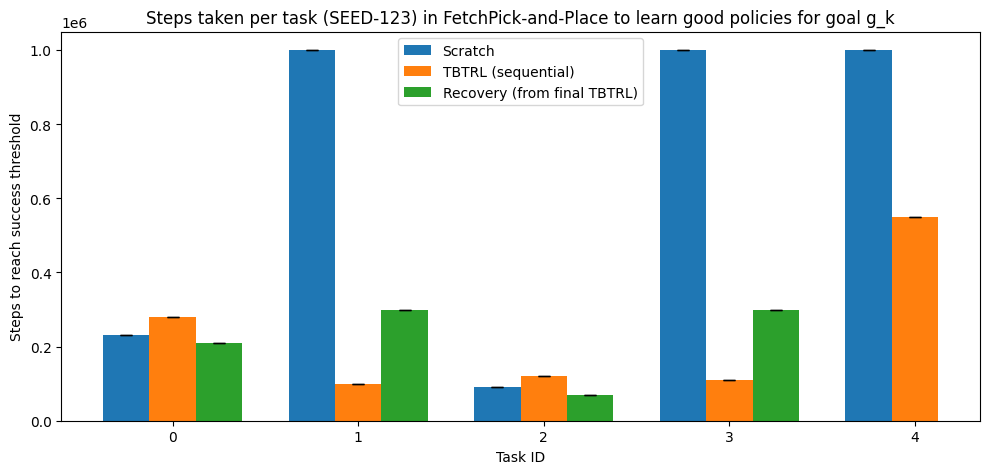

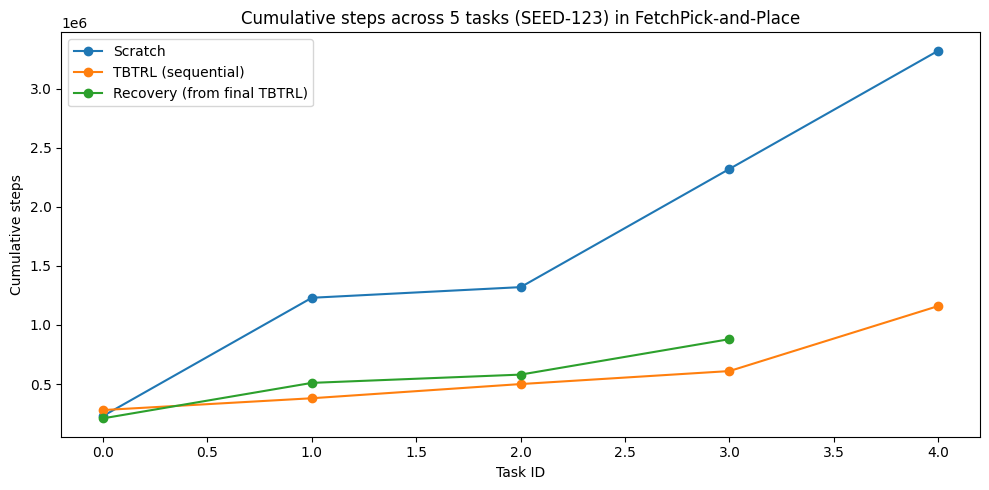

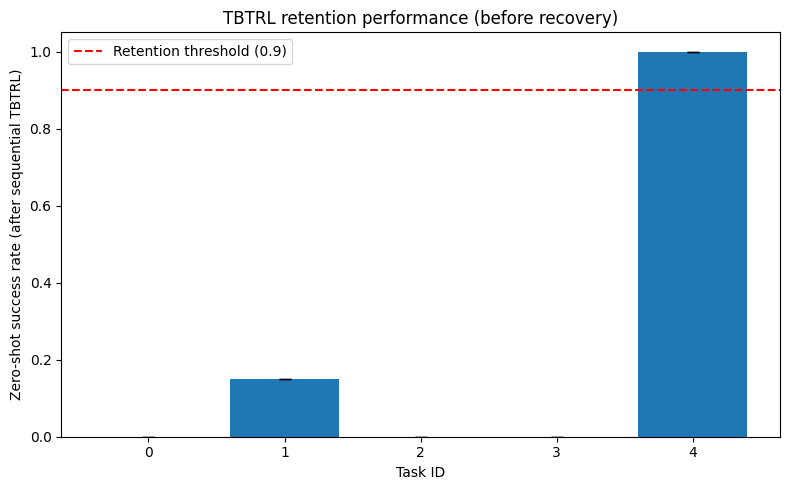

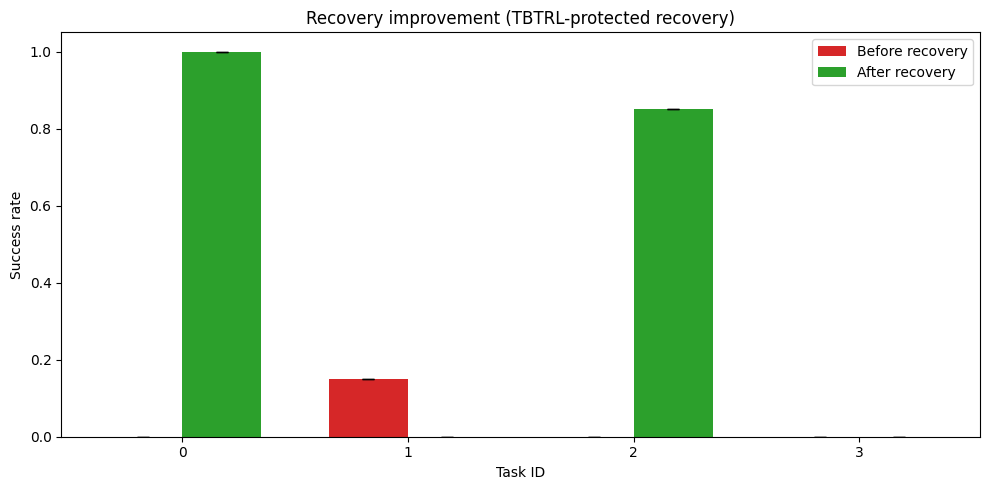

: 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# =============================================================================
# Helpers: extract per-task steps and retention
# =============================================================================

def extract_task_steps_from_scratch(results_dict, steps_key="min_steps"):
    """
    scratch_results[seed] = [ {task_id, min_steps, ...}, ... ]
    """
    task_steps = defaultdict(list)

    for seed, records in results_dict.items():
        if not isinstance(records, list):
            continue
        for rec in records:
            task_id = int(rec["task_id"])
            steps = rec.get(steps_key)
            if steps is None:
                continue
            task_steps[task_id].append(float(steps))

    return task_steps


def extract_task_steps_from_tbtrl(results_dict, steps_key="min_steps"):
    """
    tbtrl_results[seed] = {
        "task_records": [ {task_id, min_steps, ...}, ... ],
        ...
    }
    """
    task_steps = defaultdict(list)

    for seed, seed_data in results_dict.items():
        if not isinstance(seed_data, dict):
            continue
        records = seed_data.get("task_records", [])
        for rec in records:
            task_id = int(rec["task_id"])
            steps = rec.get(steps_key)
            if steps is None:
                continue
            task_steps[task_id].append(float(steps))

    return task_steps


def extract_task_steps_from_recovery(results_dict, steps_key="steps_used"):
    """
    recovery_results[seed] = {
        "retention_before": {...},
        "recovery_records": [
            {
                "task_id": ...,
                "recovery_performed": True/False,
                "steps_used": ...,
                ...
            },
            ...
        ]
    }

    Only include records where recovery_performed == True.
    """
    task_steps = defaultdict(list)

    for seed, seed_data in results_dict.items():
        if not isinstance(seed_data, dict):
            continue

        records = seed_data.get("recovery_records", [])
        for rec in records:
            if not rec.get("recovery_performed", False):
                continue

            task_id = int(rec["task_id"])
            steps = rec.get(steps_key) or rec.get("min_steps")
            if steps is None:
                continue

            task_steps[task_id].append(float(steps))

    return task_steps


def extract_tbtrl_retention(tbtrl_results_dict):
    """
    recovery_results[seed] = {
        "retention_before": {task_id: {"success_rate": ..., ...}},
        "recovery_records": [...]
    }
    """
    task_success = defaultdict(list)

    for seed, seed_data in tbtrl_results_dict.items():
        if not isinstance(seed_data, dict):
            continue

        retention_before = seed_data.get("retention_before", {})
        if isinstance(retention_before, dict):
            for task_id, metrics in retention_before.items():
                if not isinstance(metrics, dict):
                    continue
                sr = metrics.get("success_rate", 0.0)
                task_success[int(task_id)].append(float(sr))

    return task_success


def extract_recovery_improvement(recovery_results_dict):
    """
    For each task that had recovery performed, extract:
      - before success rate
      - after success rate (on the same task)

    recovery_results[seed]["recovery_records"] = [
        {
            "task_id": ...,
            "before_metrics": {"success_rate": ...},
            "after_current_task_metrics": {"success_rate": ...},
            ...
        },
        ...
    ]
    """
    before_by_task = defaultdict(list)
    after_by_task = defaultdict(list)

    for seed, seed_data in recovery_results_dict.items():
        if not isinstance(seed_data, dict):
            continue

        records = seed_data.get("recovery_records", [])
        for rec in records:
            if not rec.get("recovery_performed", False):
                continue

            task_id = int(rec["task_id"])
            before_sr = rec.get("before_metrics", {}).get("success_rate", 0.0)
            after_sr = rec.get("after_current_task_metrics", {}).get("success_rate", 0.0)

            before_by_task[task_id].append(float(before_sr))
            after_by_task[task_id].append(float(after_sr))

    return before_by_task, after_by_task


# =============================================================================
# Extract steps data for all three conditions
# =============================================================================
scratch_task_steps = None
scratch_task_steps = extract_task_steps_from_scratch(scratch_results, steps_key="min_steps")
tbtrl_task_steps = extract_task_steps_from_tbtrl(tbtrl_results, steps_key="min_steps")
recovery_task_steps = extract_task_steps_from_recovery(recovery_results, steps_key="steps_used")

# All task IDs that appear in any method
all_task_ids = sorted(
    set(scratch_task_steps.keys())
    | set(tbtrl_task_steps.keys())
    | set(recovery_task_steps.keys())
)

def mean_std_from_dict(task_dict, task_ids):
    means = []
    stds = []
    for tid in task_ids:
        vals = np.array(task_dict.get(tid, []))
        if len(vals) == 0:
            means.append(np.nan)
            stds.append(np.nan)
        else:
            means.append(vals.mean())
            stds.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)
    return np.array(means), np.array(stds)

scratch_means, scratch_stds = mean_std_from_dict(scratch_task_steps, all_task_ids)
tbtrl_means, tbtrl_stds = mean_std_from_dict(tbtrl_task_steps, all_task_ids)
recovery_means, recovery_stds = mean_std_from_dict(recovery_task_steps, all_task_ids)


# =============================================================================
# Plot 1: Steps per task (scratch vs TBTRL vs recovery)
# =============================================================================

x = np.arange(len(all_task_ids))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width,
    scratch_means,
    width,
    yerr=scratch_stds,
    label="Scratch",
    capsize=4,
)

bars2 = ax.bar(
    x,
    tbtrl_means,
    width,
    yerr=tbtrl_stds,
    label="TBTRL (sequential)",
    capsize=4,
)

bars3 = ax.bar(
    x + width,
    recovery_means,
    width,
    yerr=recovery_stds,
    label="Recovery (from final TBTRL)",
    capsize=4,
)

ax.set_xlabel("Task ID")
ax.set_ylabel("Steps to reach success threshold")
ax.set_title("Steps taken per task (SEED-123) in FetchPick-and-Place to learn good policies for goal g_k")
ax.set_xticks(x)
ax.set_xticklabels([str(t) for t in all_task_ids])
ax.legend()

plt.tight_layout()
plt.show()


# =============================================================================
# Plot 2: Cumulative steps across tasks
# =============================================================================

scratch_cum = np.cumsum(scratch_means)
tbtrl_cum = np.cumsum(tbtrl_means)
recovery_cum = np.cumsum(recovery_means)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    all_task_ids,
    scratch_cum,
    marker="o",
    label="Scratch",
)

ax.plot(
    all_task_ids,
    tbtrl_cum,
    marker="o",
    label="TBTRL (sequential)",
)

ax.plot(
    all_task_ids,
    recovery_cum,
    marker="o",
    label="Recovery (from final TBTRL)",
)

ax.set_xlabel("Task ID")
ax.set_ylabel("Cumulative steps")
ax.set_title("Cumulative steps across 5 tasks (SEED-123) in FetchPick-and-Place")
ax.legend()
plt.tight_layout()
plt.show()


# =============================================================================
# Plot 3: TBTRL retention (zero-shot) before recovery
# =============================================================================

tbtrl_retention = extract_tbtrl_retention(recovery_results)

task_ids_ret = sorted(tbtrl_retention.keys())
ret_means = []
ret_stds = []

for tid in task_ids_ret:
    vals = np.array(tbtrl_retention[tid])
    ret_means.append(vals.mean())
    ret_stds.append(vals.std(ddof=1) if len(vals) > 1 else 0.0)

ret_means = np.array(ret_means)
ret_stds = np.array(ret_stds)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    task_ids_ret,
    ret_means,
    yerr=ret_stds,
    capsize=4,
    color="C0",
)

ax.axhline(
    0.9,
    color="red",
    linestyle="--",
    label="Retention threshold (0.9)",
)

ax.set_xlabel("Task ID")
ax.set_ylabel("Zero-shot success rate (after sequential TBTRL)")
ax.set_title("TBTRL retention performance (before recovery)")
ax.set_xticks(task_ids_ret)
ax.set_xticklabels([str(t) for t in task_ids_ret])
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()


# =============================================================================
# Plot 4: Recovery improvement (before vs after)
# =============================================================================

before_by_task, after_by_task = extract_recovery_improvement(recovery_results)

# Use union of task IDs that had recovery performed
recovery_task_ids = sorted(
    set(before_by_task.keys()) | set(after_by_task.keys())
)

before_means = []
before_stds = []
after_means = []
after_stds = []

for tid in recovery_task_ids:
    b_vals = np.array(before_by_task.get(tid, []))
    a_vals = np.array(after_by_task.get(tid, []))

    before_means.append(b_vals.mean() if len(b_vals) > 0 else np.nan)
    before_stds.append(b_vals.std(ddof=1) if len(b_vals) > 1 else 0.0)

    after_means.append(a_vals.mean() if len(a_vals) > 0 else np.nan)
    after_stds.append(a_vals.std(ddof=1) if len(a_vals) > 1 else 0.0)

before_means = np.array(before_means)
before_stds = np.array(before_stds)
after_means = np.array(after_means)
after_stds = np.array(after_stds)

x_rec = np.arange(len(recovery_task_ids))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x_rec - width/2,
    before_means,
    width,
    yerr=before_stds,
    label="Before recovery",
    capsize=4,
    color="C3",
)

ax.bar(
    x_rec + width/2,
    after_means,
    width,
    yerr=after_stds,
    label="After recovery",
    capsize=4,
    color="C2",
)

ax.set_xlabel("Task ID")
ax.set_ylabel("Success rate")
ax.set_title("Recovery improvement (TBTRL-protected recovery)")
ax.set_xticks(x_rec)
ax.set_xticklabels([str(t) for t in recovery_task_ids])
ax.set_ylim(0, 1.05)
ax.legend()

plt.tight_layout()
plt.show()